In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.float_format', lambda x: '%.3f' % x)
# '..' moves up out of 'notebooks/' into the root project folder, then goes into 'data/'
csv_path = os.path.join("..", "data", "loan_default.csv")

try:
    # Load the dataset
    df = pd.read_csv(csv_path)
    print(f"Successfully loaded the dataset!")
    print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

    # Display the first few rows
    #display(df.head())

except FileNotFoundError:
    print(f"Error: Could not find the file at '{csv_path}'.")
    print("Double-check if the file name is lowercase 'loan_default.csv' or capitalized 'Loan_Default.csv'.")

Successfully loaded the dataset!
Dataset Shape: 148670 rows, 34 columns



In [4]:
print(f"Column Names and Datatypes")
df.info()

Column Names and Datatypes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Up

In [53]:
print("Ratio of Non Default and  Default")
custom_labels = {
    0: "Non Default",
    1: "Default"
}
    
ratios = df['Status'].value_counts(normalize=True) * 100
for val, percentage in ratios.items():
    # Fallback to val if it's not in the dictionary
    label = custom_labels.get(val, val) 
    print(f"Status: {label} -> {percentage:.1f}%")


Ratio of Non Default and  Default
Status: Non Default -> 75.4%
Status: Default -> 24.6%


In [54]:
# 1. Define specific renames for cryptic or shorthand columns
rename_dict = {
    "approv_in_adv": "approved_in_advance",
    "Neg_ammortization": "negative_amortization",
    "co-applicant_credit_type": "co_applicant_credit_type",
    "dtir1": "debt_to_income_ratio",
    "LTV": "loan_to_value_ratio",
    "ID": "loan_id",
}

# 2. Apply explicit renames first
df = df.rename(columns=rename_dict)

# 3. Standardize everything else to clean lowercase_snake_case
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

In [55]:
# Get a list of all numeric column names
numeric_cols = df.select_dtypes(include='number').columns.tolist()
display(numeric_cols)

['loan_id',
 'year',
 'loan_amount',
 'rate_of_interest',
 'interest_rate_spread',
 'upfront_charges',
 'term',
 'property_value',
 'income',
 'credit_score',
 'loan_to_value_ratio',
 'status',
 'debt_to_income_ratio']

In [56]:
# Get a list of all category column names
category_cols = df.select_dtypes(include='object').columns.tolist()
display(category_cols)

['loan_limit',
 'gender',
 'approved_in_advance',
 'loan_type',
 'loan_purpose',
 'credit_worthiness',
 'open_credit',
 'business_or_commercial',
 'negative_amortization',
 'interest_only',
 'lump_sum_payment',
 'construction_type',
 'occupancy_type',
 'secured_by',
 'total_units',
 'credit_type',
 'co_applicant_credit_type',
 'age',
 'submission_of_application',
 'region',
 'security_type']

In [34]:
df.describe(include='number').T[['min','max','mean','std']].assign(
    ratio=lambda x: x['max']/x['mean']
).sort_values('ratio',ascending=False)

,min,max,mean,std,ratio
loan_to_value_ratio,0.967,7831.250,72.746,39.968,107.651
income,0.000,578580.000,6957.339,6496.586,83.161
property_value,8000.000,16508000.000,497893.466,359935.316,33.156
upfront_charges,0.000,60000.000,3224.996,3251.122,18.605
loan_amount,16500.000,3576500.000,331117.744,183909.310,10.801
interest_rate_spread,-3.638,3.357,0.442,0.513,7.601
status,0.000,1.000,0.246,0.431,4.058
rate_of_interest,0.000,8.000,4.045,0.561,1.978
loan_id,24890.000,173559.000,99224.500,42917.477,1.749
debt_to_income_ratio,5.000,61.000,37.733,10.545,1.617


In [57]:
df.describe(include='object').T.assign(
    dominance_pct=lambda x: (x['freq'] / x['count'] * 100).astype(float)
).sort_values('dominance_pct', ascending=False)

,count,unique,top,freq,dominance_pct
security_type,148670,2,direct,148637,99.978
secured_by,148670,2,home,148637,99.978
construction_type,148670,2,sb,148637,99.978
open_credit,148670,2,nopc,148114,99.626
total_units,148670,4,1U,146480,98.527
lump_sum_payment,148670,2,not_lpsm,145286,97.724
credit_worthiness,148670,2,l1,142344,95.745
interest_only,148670,2,not_int,141560,95.218
loan_limit,145326,2,cf,135348,93.134
occupancy_type,148670,3,pr,138201,92.958


In [58]:
# Pass numeric_only=True to prevent strings from breaking the calculation
status_corr = df.corr(numeric_only=True)['status'].sort_values(ascending=False)

print(status_corr)

status                  1.000
debt_to_income_ratio    0.078
loan_to_value_ratio     0.039
rate_of_interest        0.023
credit_score            0.004
loan_id                 0.002
term                   -0.000
upfront_charges        -0.019
loan_amount            -0.037
property_value         -0.049
income                 -0.065
year                      NaN
interest_rate_spread      NaN
Name: status, dtype: float64


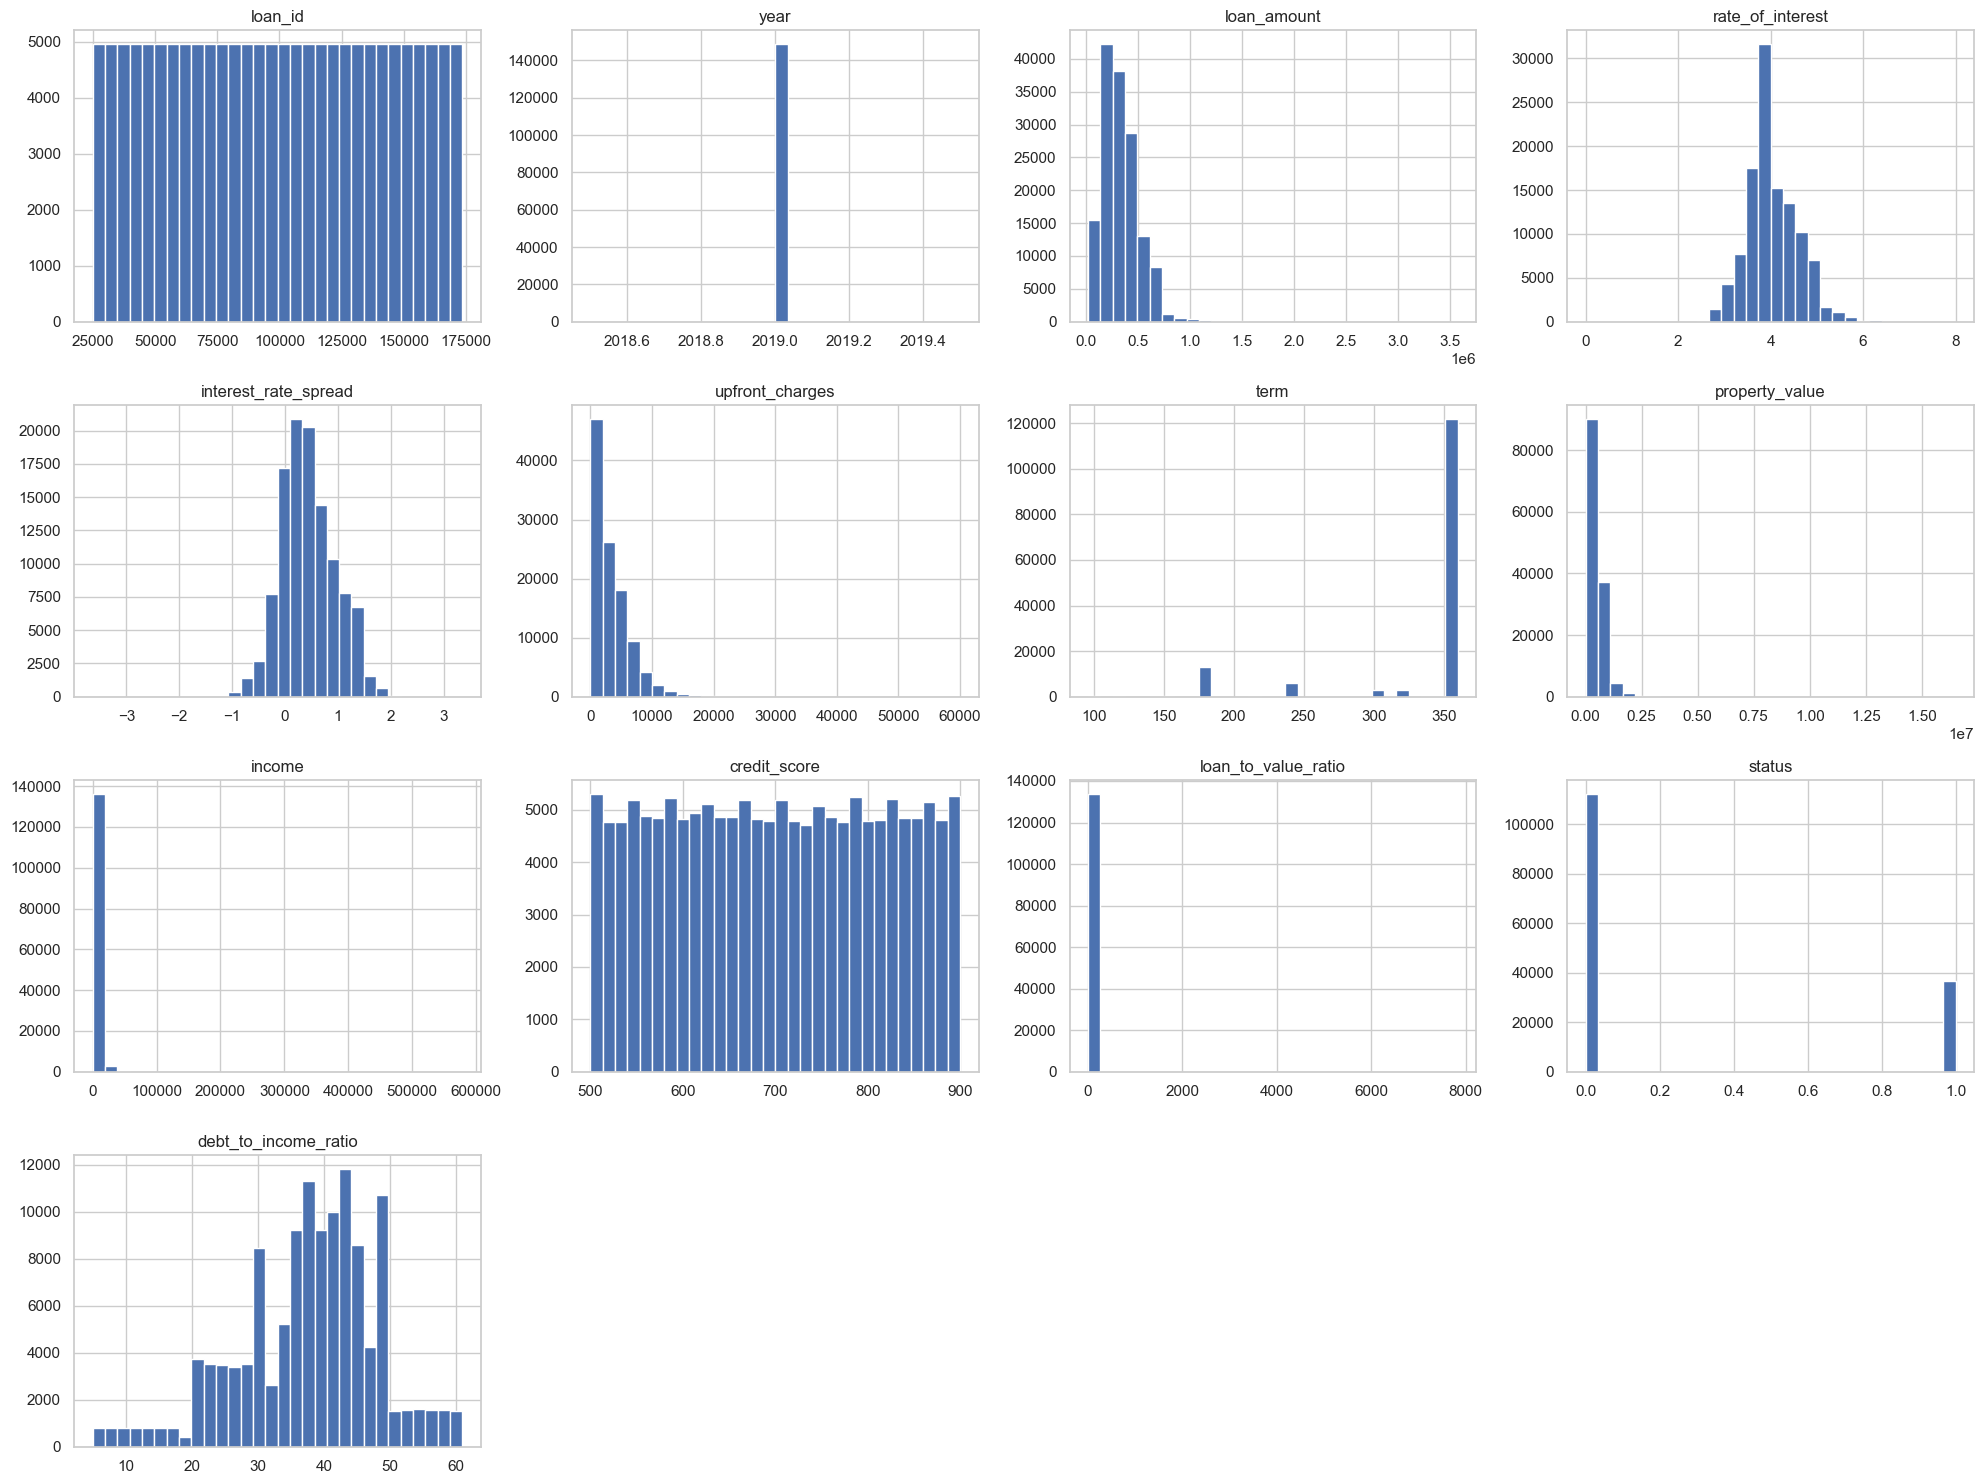

In [63]:

df.hist(figsize=(20, 15), bins=30)
plt.tight_layout()
plt.savefig('../output/feature_distributions.png')
plt.show()

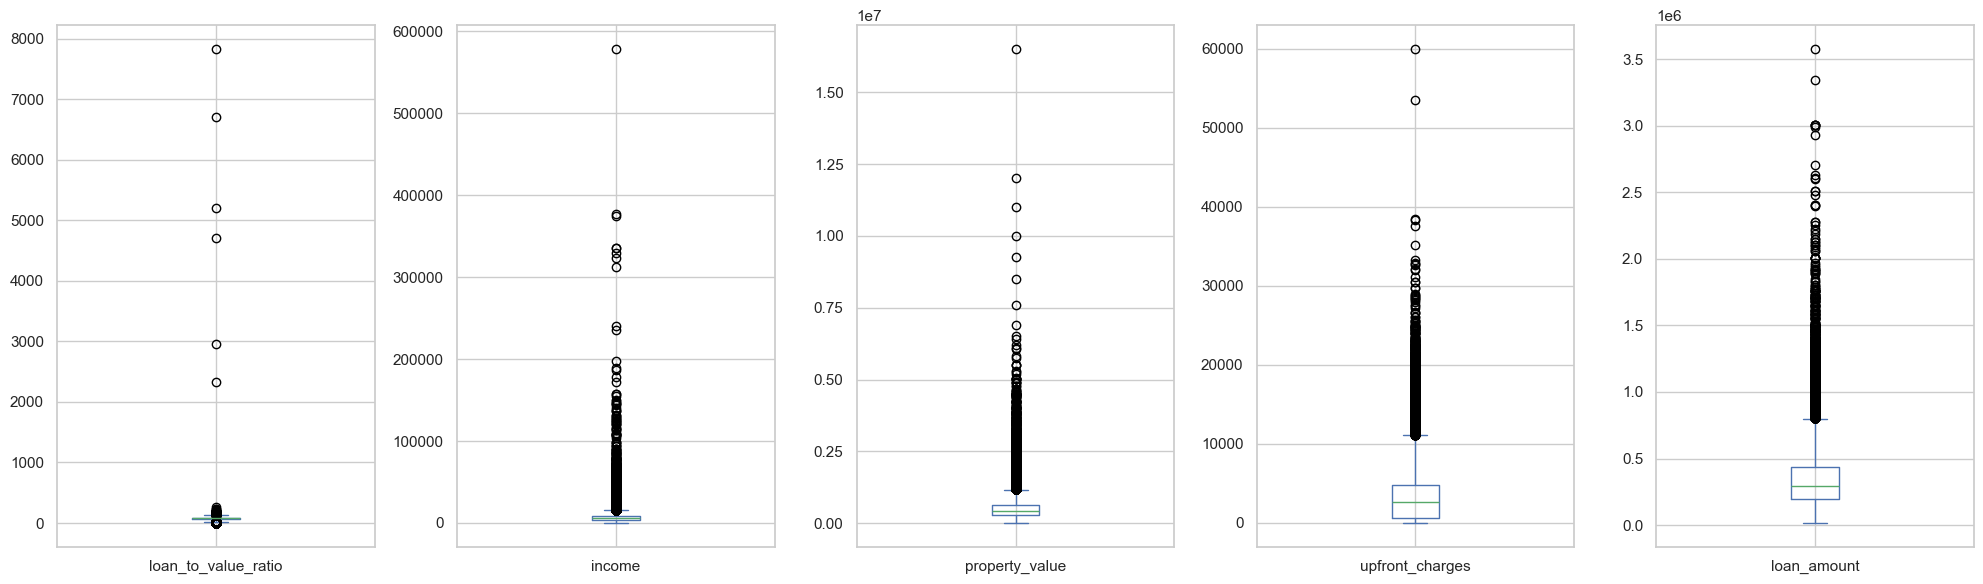

In [60]:
cols = ['loan_to_value_ratio', 'income', 'property_value', 'upfront_charges', 'loan_amount']
df[cols].plot(kind='box', subplots=True, figsize=(20, 6), layout=(1,5))
plt.tight_layout()
plt.savefig('../output/outlier_boxplots.png')
plt.show()

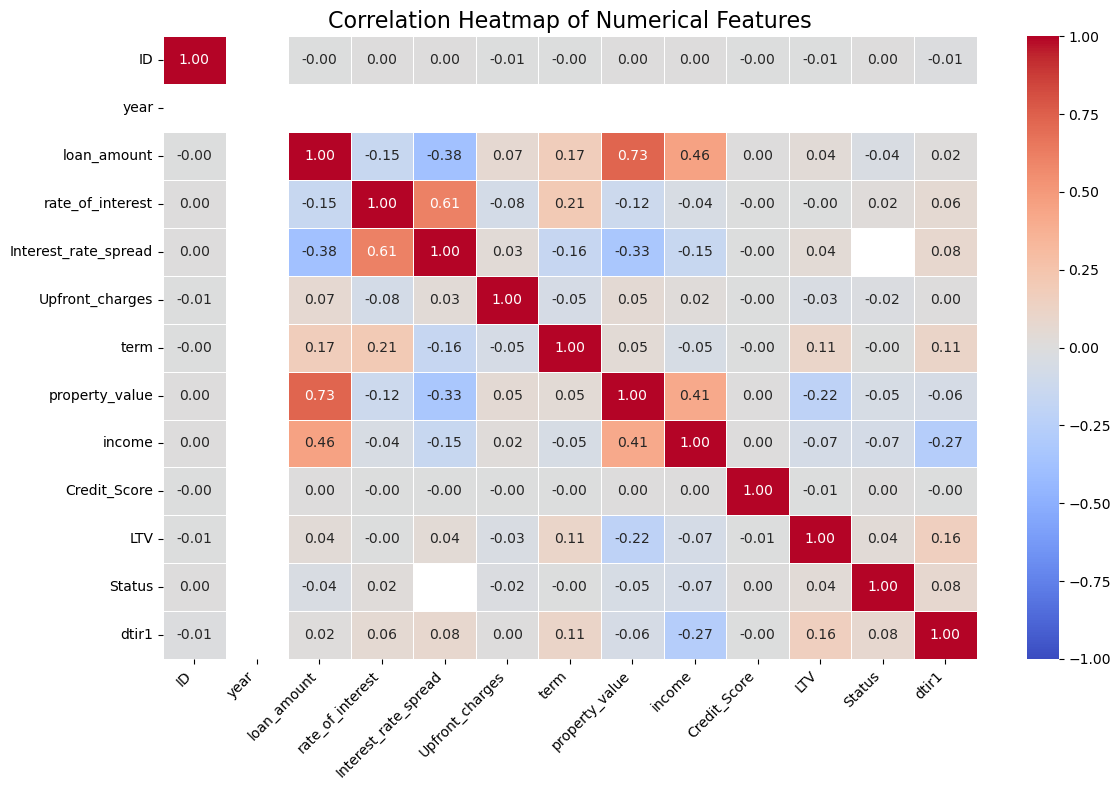

In [5]:
# Pass numeric_only=True to prevent strings from breaking the calculation
status_corr = df.corr(numeric_only=True)

# Create a large figure so the labels don't get cramped
plt.figure(figsize=(12, 8))

# Generate the heatmap
sns.heatmap(
    status_corr, 
    annot=True,          # Show the actual correlation numbers in the boxes
    cmap='coolwarm',     # Use a blue (negative) to red (positive) color scale
    fmt=".2f",           # Format the numbers to 2 decimal places
    vmin=-1, vmax=1,     # Set the scale from -1 to 1
    linewidths=0.5       # Add light gridlines to separate the boxes
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.xticks(rotation=45, ha='right') # Rotate x-labels for better readability
plt.tight_layout()
plt.savefig('../output/correlationheatmap.png')
plt.show()

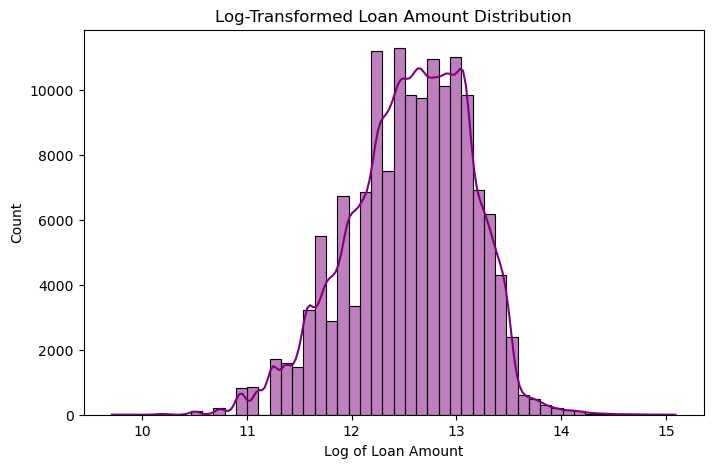

In [7]:
import numpy as np

# Apply a log transformation to compress the massive outliers and reveal the bell curve
plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(df['loan_amount']), bins=50, kde=True, color='purple')
plt.title('Log-Transformed Loan Amount Distribution')
plt.xlabel('Log of Loan Amount')
plt.show()

In [ ]:
# LTV max of 7831 — investigate whether to cap or remove
# Income and rate_of_interest zeros — test for MAR before imputing
# Year column — drop, it's a constant
# Negative interest spread — valid range needs a domain decision (is -3.64 real or error?)